## Exercise 1 - Bayes classification system

In [47]:
# Import some useful libraries

import math

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from collections import defaultdict
from sklearn.metrics import accuracy_score

## 1a. Getting started with Bayes

a) Read the training data from file ex1-data-train.csv. The first two columns are x1 and x2. The last column holds the class label y.

In [2]:
def read_data(file):
    dataset = pd.read_csv(file, names=['x1','x2','y'])
    print(dataset.head())
    return dataset[["x1", "x2"]], dataset["y"].values

In [3]:
X_train, y_train = read_data("ex1-data-train.csv")

          x1         x2  y
0  34.623660  78.024693  0
1  30.286711  43.894998  0
2  35.847409  72.902198  0
3  60.182599  86.308552  1
4  79.032736  75.344376  1


In [4]:
# Prepare a function to compute accuracy
def accuracy_score(y_true, y_pred):
    return (y_true == y_pred).sum() / y_true.size

b) Compute the priors of both classes P(C0) and P(C1)

In [16]:
# TODO: Compute the priors
def compute_priors(y):
    count = defaultdict(type(y[0]))

    for label in y:
        count[label] += 1

    return count

In [17]:
priors = compute_priors(y_train)
priors

defaultdict(numpy.int64,
            {np.int64(0): np.int64(40), np.int64(1): np.int64(60)})

c) Compute histograms of x1 and x2 for each class (total of 4 histograms). Plot these histograms. Advice : use the numpy `histogram(a, bins="auto")` function.

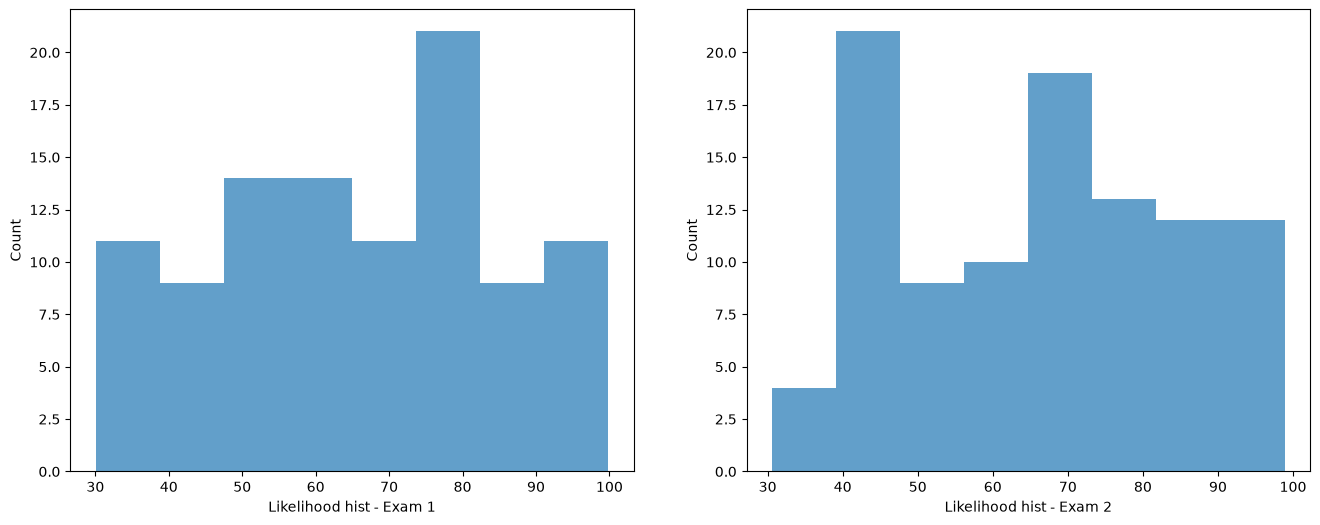

In [25]:
# TODO: Compute histograms
def compute_histogram(values):
    counts, edges = np.histogram(values, bins="auto")
    return counts, edges

counts_x1, edges_x1 = compute_histogram(X_train["x1"])
counts_x2, edges_x2 = compute_histogram(X_train["x2"])

# Bin centers and widths
width_x1 = edges_x1[1] - edges_x1[0]
centers_x1 = (edges_x1[:-1] + edges_x1[1:]) / 2

width_x2 = edges_x2[1] - edges_x2[0]
centers_x2 = (edges_x2[:-1] + edges_x2[1:]) / 2

# TODO: plot histograms
plt.figure(figsize=(16, 6))

plt.subplot(1, 2, 1)
plt.bar(centers_x1, counts_x1, width=width_x1, alpha=0.7)
plt.xlabel('Likelihood hist - Exam 1')
plt.ylabel('Count')

plt.subplot(1, 2, 2)
plt.bar(centers_x2, counts_x2, width=width_x2, alpha=0.7)
plt.xlabel('Likelihood hist - Exam 2')
plt.ylabel('Count')

plt.show()

d) Use the histograms to compute the likelihoods p(x1|C0), p(x1|C1), p(x2|C0) and p(x2|C1). For this define a function `likelihood_hist(x, hist_values, edge_values)` that returns the likelihood of x for a given histogram (defined by its values and bin edges as returned by the numpy `histogram()` function).

In [37]:
def likelihood_hist(x: float, hist_values: np.ndarray, bin_edges: np.ndarray) -> float:
    """
    Return p(x | C) from a histogram (as returned by np.histogram).

    x            : scalar value to evaluate
    hist_values  : counts per bin
    bin_edges    : bin edges (length = len(hist_values) + 1)
    """
    hist_values = np.asarray(hist_values, dtype=float)
    bin_edges = np.asarray(bin_edges, dtype=float)

    # Normalize counts to probabilities
    probs = hist_values / hist_values.sum()

    # x outside the histogram range -> likelihood 0
    if x < bin_edges[0] or x > bin_edges[-1]:
        return 0.0

    # Find the bin containing x
    idx = np.searchsorted(bin_edges, x, side='right') - 1
    idx = min(idx, len(probs) - 1)

    return probs[idx]

e) Implement the classification decision according to Bayes rule and compute the overall accuracy of the system on the test set ex1-data-test.csv. :
- using only feature x1
- using only feature x2
- using x1 and x2 making the naive Bayes hypothesis of feature independence, i.e. p(X|Ck) = p(x1|Ck) · p(x2|Ck)

In [38]:
X_test, y_test = read_data("ex1-data-test.csv")

          x1         x2  y
0  39.196334  78.530294  0
1  40.448499  86.839470  1
2  65.571920  44.303497  0
3  79.648113  70.806564  1
4  66.260221  41.672703  0


In [48]:
def train_nb_hist(X_train, y_train):
    classes = np.unique(y_train)
    priors = compute_priors(y_train)

    # Per-class histograms for both features
    model = {}
    for c in classes:
        model[c] = {
            "x1": compute_histogram(X_train.loc[y_train == c, "x1"]),
            "x2": compute_histogram(X_train.loc[y_train == c, "x2"]),
        }
        
    return priors, model, classes

def predict_nb(X, priors, model, classes, features=("x1", "x2")):
    predictions = []

    for _, row in X.iterrows():
        scores = {}
        for c in classes:
            score = priors[c]
            for f in features:
                counts, edges = model[c][f]
                score *= likelihood_hist(row[f], counts, edges)
            scores[c] = score

        predictions.append(max(scores, key=scores.get))

    return np.array(predictions)

In [49]:
# TODO: predict on test set in the 3 cases described above
priors, model, classes = train_nb_hist(X_train, y_train)

# Only x1
pred_x1 = predict_nb(X_test, priors, model, classes, features=("x1",))
print("Accuracy (x1 only):", accuracy_score(y_test, pred_x1))

# Only x2
pred_x2 = predict_nb(X_test, priors, model, classes, features=("x2",))
print("Accuracy (x2 only):", accuracy_score(y_test, pred_x2))

# (x1 and x2 together
pred_both = predict_nb(X_test, priors, model, classes, features=("x1", "x2"))
print("Accuracy (x1 + x2):", accuracy_score(y_test, pred_both))

Accuracy (x1 only): 0.7
Accuracy (x2 only): 0.73
Accuracy (x1 + x2): 0.88


Which system is the best ?

With both features!

## 1b. Bayes - Univariate Gaussian distribution

Do the same as in a) but this time using univariate Gaussian distribution to model the likelihoods p(x1|C0), p(x1|C1), p(x2|C0) and p(x2|C1). You may use the numpy functions `mean()` and `var()` to compute the mean μ and variance σ2 of the distribution. To model the likelihood of both features, you may also do the naive Bayes hypothesis of feature independence, i.e. p(X|Ck) = p(x1|Ck) · p(x2|Ck).


In [44]:
def likelihood_univariate_gaussian(x: float, mean: float, var: float) -> float:
    return (1.0 / np.sqrt(2 * np.pi * var)) * np.exp(-((x - mean) ** 2) / (2 * var))

In [46]:
# TODO: Compute mean and variance for each classes and each features (8 values)
model_gauss = {
    c: {
        f: (X_train.loc[y_train == c, f].mean(),
            X_train.loc[y_train == c, f].var())
        for f in ("x1", "x2")
    }
    for c in classes
}

model_gauss


{np.int64(0): {'x1': (np.float64(52.032301098426046),
   np.float64(307.96914597065785)),
  'x2': (np.float64(54.62039209636222), np.float64(258.6175676229705))},
 np.int64(1): {'x1': (np.float64(74.71892269658788),
   np.float64(222.38025620496546)),
  'x2': (np.float64(73.9564020826201), np.float64(256.3970646319845))}}

In [50]:
# Only x1
y_pred = []

for _, row in X_test.iterrows():
    scores = {}
    for c in classes:
        mean, var = model_gauss[c]["x1"]
        scores[c] = priors[c] * likelihood_univariate_gaussian(row["x1"], mean, var)
    y_pred.append(max(scores, key=scores.get))

print("Gaussian accuracy (x1 only):", accuracy_score(y_test, y_pred))


# Only x2
y_pred = []

for _, row in X_test.iterrows():
    scores = {}
    for c in classes:
        mean, var = model_gauss[c]["x2"]
        scores[c] = priors[c] * likelihood_univariate_gaussian(row["x2"], mean, var)
    y_pred.append(max(scores, key=scores.get))

print("Gaussian accuracy (x2 only):", accuracy_score(y_test, y_pred))


# x1 and x2
y_pred = []

for _, row in X_test.iterrows():
    scores = {}
    for c in classes:
        mean1, var1 = model_gauss[c]["x1"]
        mean2, var2 = model_gauss[c]["x2"]
        likelihood = (likelihood_univariate_gaussian(row["x1"], mean1, var1) *
                      likelihood_univariate_gaussian(row["x2"], mean2, var2))
        scores[c] = priors[c] * likelihood
    y_pred.append(max(scores, key=scores.get))

print("Gaussian accuracy (x1 + x2):", accuracy_score(y_test, y_pred))

Gaussian accuracy (x1 only): 0.7
Gaussian accuracy (x2 only): 0.72
Gaussian accuracy (x1 + x2): 0.89


We clearly see that the performances are very similar, meaning that our initial distribution is probably a gaussian